# 04 · Error analysis, robustness and Week 2 summary

Notebook độc lập cho kernel Kaggle mới, triển khai Phase 6 và tạo tổng hợp định lượng cho Phase 7. Các classifier được load từ artifact Phase 5, giữ threshold 0.5 và không huấn luyện lại.

## Input trước khi chạy

1. Bật GPU và Internet; thêm Kaggle Secret `HF_TOKEN` đã có quyền checkpoint DINOv3.
2. Add Input dataset Who Is AI chứa `train/manifest.csv`, `train/images/`.
3. Add Input cache/ZIP Phase 4 (output notebook 02).
4. Add Input artifact/ZIP Phase 5 (output notebook 03).
5. Nên thêm artifact/ZIP Phase 3 để đối chiếu trực tiếp baseline cũ; nếu thiếu, notebook vẫn chạy và ghi rõ giới hạn của diagnostic.
6. Đồng bộ code mới nhất lên GitHub hoặc attach snapshot repo có `src/evaluation/phase6.py`. Cell setup không dùng source/kernel từ notebook khác.

Có thể gán `PHASE4_ROOT`, `PHASE5_ROOT`, `PHASE3_ROOT` (thư mục artifact hoặc ZIP) và `DATA_ROOT` thủ công. Khi nhiều input cùng loại, notebook yêu cầu chọn rõ thay vì lấy ngẫu nhiên.

## Protocol đã cố định

- Chỉ 400 ảnh validation từ split seed 42, giữ nguyên ID/thứ tự/nhãn.
- Error cases: Global-only so với Global + Local và Local-only, confidence tại threshold 0.5; montage lấy mẫu seed 42.
- Corruption áp dụng riêng lẻ trên RGB gốc sau EXIF transpose, trước processor đã lưu: JPEG quality 70/subsampling 2; resize bilinear 112→224; Gaussian blur radius 1.0 pixel trên ảnh gốc.
- Clean và corrupted đều trích DINOv3 tại đúng model revision của cache, dùng AMP float16 và chuyển sang float32 cho classifier. Đối chiếu thêm clean float32 để đo ảnh hưởng precision.
- Lưu metrics và chênh lệch so với clean; không chọn lại checkpoint hay threshold bằng robustness.
- Kết quả là diagnostic in-domain. H1 về unseen-source generalization vẫn chưa xác định được.

Artifact tại `/kaggle/working/phase6_outputs/dinov3_seed42/`. Tổng hợp được hiển thị cuối notebook và lưu JSON; kết quả cuối tuần được ghi tiếp vào `docs/week02.md` sau khi review output.


In [1]:
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/AIVIETNAM-AIO-DinhBao/FaceTrace.git"
REPO_DIR = Path("/kaggle/working/FaceTrace")
# Gán REPO_DIR thủ công nếu attach repo với tên khác.
attached = [Path("/kaggle/input/facetrace"), Path("/kaggle/input/face-trace")]
if not (REPO_DIR / "src").is_dir():
    repository_input = next((p for p in attached if (p / "src").is_dir()), None)
    if repository_input is not None:
        REPO_DIR = repository_input
    else:
        if REPO_DIR.exists() and any(REPO_DIR.iterdir()):
            raise RuntimeError("REPO_DIR đã có dữ liệu khác; chọn một đường dẫn repo trống.")
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(REPO_DIR)], check=True)

required = ["src/evaluation/phase6.py", "src/models/dinov3.py", "src/models/classifier.py"]
missing = [name for name in required if not (REPO_DIR / name).is_file()]
if missing:
    raise FileNotFoundError(f"Repo thiếu {missing}. Push code Phase 6 lên main hoặc attach snapshot mới rồi chạy session mới.")
sys.path.insert(0, str(REPO_DIR))
print("Repo:", REPO_DIR)


Cloning into '/kaggle/working/FaceTrace'...


Repo: /kaggle/working/FaceTrace


In [2]:
%pip install -q "transformers==4.57.6" "pandas>=2.2" "Pillow>=10" "scikit-learn>=1.4" "PyYAML>=6" "tqdm>=4.66" "matplotlib>=3.8"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import os
import platform
import random
import shutil
from importlib.metadata import version

import numpy as np
import pandas as pd
import torch
from IPython.display import Image as DisplayImage, Markdown, display

from src.evaluation.phase6 import (
    CONDITIONS, REPRESENTATIONS, file_hash, find_artifact, load_phase4,
    load_phase5, load_classifier, resolve_validation_images, predict_features,
    score_predictions, verify_phase5_replay, error_groups, save_error_montages,
    extract_validation, compare_features, robustness_deltas, save_robustness_plot,
)

if not torch.cuda.is_available():
    raise RuntimeError("Chọn Kaggle Settings → Accelerator → GPU rồi chạy session mới.")

PHASE4_ROOT = Path("/kaggle/input/datasets/dinhbaobao/output02-artifacts/phase4_dinov3_feature_cache")
PHASE5_ROOT = Path("/kaggle/input/datasets/dinhbaobao/output03-artifacts/phase5_local_experiment_artifacts")
PHASE3_ROOT = Path("/kaggle/input/datasets/dinhbaobao/output01-artifacts/phase3_baseline_artifacts")
DATA_ROOT = Path("/kaggle/input/datasets/dinhbaobao/who-is-ai/data")
SEED = 42
BATCH_SIZE = 32
DEVICE = torch.device("cuda")
OUTPUT_DIR = Path("/kaggle/working/phase6_outputs/dinov3_seed42")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.set_float32_matmul_precision("highest")

def save_json(name, value):
    (OUTPUT_DIR / name).write_text(
        json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False) + "\n", encoding="utf-8"
    )

print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch:", torch.__version__)


GPU: Tesla T4
PyTorch: 2.10.0+cu128


In [4]:
INPUT_ROOT = Path("/kaggle/input")
UNPACK_ROOT = Path("/kaggle/working/phase6_inputs")
PHASE4_ROOT = find_artifact(INPUT_ROOT, UNPACK_ROOT, "phase4", explicit=PHASE4_ROOT)
PHASE5_ROOT = find_artifact(INPUT_ROOT, UNPACK_ROOT, "phase5", explicit=PHASE5_ROOT)
PHASE3_ROOT = find_artifact(INPUT_ROOT, UNPACK_ROOT, "phase3", explicit=PHASE3_ROOT, required=False)

if DATA_ROOT is None:
    candidates = [p.parent.parent for p in INPUT_ROOT.rglob("manifest.csv")
                  if p.parent.name == "train" and (p.parent / "images").is_dir()]
    if len(candidates) != 1:
        raise ValueError(f"Tìm được {len(candidates)} dataset candidates; đặt DATA_ROOT thủ công: {candidates}")
    DATA_ROOT = candidates[0]
DATA_ROOT = Path(DATA_ROOT)
TRAIN_ROOT = DATA_ROOT / "train"

for phase, root in [("Phase 4", PHASE4_ROOT), ("Phase 5", PHASE5_ROOT), ("Phase 3 optional", PHASE3_ROOT)]:
    print(phase, ":", root)
print("Dataset:", DATA_ROOT)


Phase 4 : /kaggle/input/datasets/dinhbaobao/output02-artifacts/phase4_dinov3_feature_cache
Phase 5 : /kaggle/input/datasets/dinhbaobao/output03-artifacts/phase5_local_experiment_artifacts
Phase 3 optional : /kaggle/input/datasets/dinhbaobao/output01-artifacts/phase3_baseline_artifacts
Dataset: /kaggle/input/datasets/dinhbaobao/who-is-ai/data


In [5]:
cache = load_phase4(PHASE4_ROOT)
metadata = cache["metadata"]
validation_paths = resolve_validation_images(cache["validation_rows"], TRAIN_ROOT)
metadata["resolved_image_path"] = [str(p) for p in validation_paths]
image_paths_by_id = dict(zip(metadata.image_id, validation_paths))

heads, checkpoints, phase5_results, phase5_config = load_phase5(PHASE5_ROOT, cache, DEVICE)
cached_predictions = predict_features(
    heads, cache["features"], metadata, DEVICE, condition="clean_cached", batch_size=BATCH_SIZE
)
replay_status = verify_phase5_replay(PHASE5_ROOT, cached_predictions, phase5_results)
cached_metrics = score_predictions(cached_predictions)
display(replay_status)
display(cached_metrics)
cached_predictions.to_csv(OUTPUT_DIR / "cached_validation_predictions.csv", index=False)
replay_status.to_csv(OUTPUT_DIR / "checkpoint_replay.csv", index=False)

repo_commit = subprocess.run(["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"],
                             capture_output=True, text=True).stdout.strip() or "attached snapshot"
provenance = {
    "repo_commit": repo_commit,
    "phase6_module_sha256": file_hash(REPO_DIR / "src/evaluation/phase6.py"),
    "artifact_roots": {"phase4": str(PHASE4_ROOT), "phase5": str(PHASE5_ROOT),
                       "phase3": str(PHASE3_ROOT) if PHASE3_ROOT else None},
    "model_id": cache["manifest"]["model_id"],
    "model_revision": cache["manifest"]["model_revision"],
    "seed": SEED, "batch_size": BATCH_SIZE, "threshold": 0.5,
    "split_counts": cache["counts"], "conditions": CONDITIONS,
    "classifier_config": phase5_config["model"], "training_config": phase5_config["training"],
    "feature_precision": "AMP float16, then float32 for heads", "classifier_precision": "float32",
    "source_metadata_available": False, "evaluation_claim": "in-domain validation diagnostic only",
    "python": platform.python_version(), "gpu": torch.cuda.get_device_name(0),
    "packages": {name: version(name) for name in ["torch", "transformers", "numpy", "pandas", "Pillow", "scikit-learn"]},
    "input_sha256": {
        "phase4/metadata.csv": file_hash(PHASE4_ROOT / "metadata.csv"),
        "phase4/val.csv": file_hash(PHASE4_ROOT / "val.csv"),
        "phase4/processor.json": file_hash(PHASE4_ROOT / "processor.json"),
        "phase4/cache_manifest.json": file_hash(PHASE4_ROOT / "cache_manifest.json"),
        "phase5/config.yaml": file_hash(PHASE5_ROOT / "config.yaml"),
        "phase5/results.json": file_hash(PHASE5_ROOT / "results.json"),
        "raw_dataset/manifest.csv": file_hash(TRAIN_ROOT / "manifest.csv"),
        **{f"phase5/{name}/best_classifier.pt": file_hash(PHASE5_ROOT / name / "best_classifier.pt")
           for name in REPRESENTATIONS},
    },
}
save_json("protocol_environment.json", provenance)
shutil.copy2(PHASE4_ROOT / "val.csv", OUTPUT_DIR / "val.csv")
shutil.copy2(PHASE4_ROOT / "cache_manifest.json", OUTPUT_DIR / "cache_manifest.json")
shutil.copy2(PHASE4_ROOT / "processor.json", OUTPUT_DIR / "processor.json")
shutil.copy2(PHASE5_ROOT / "config.yaml", OUTPUT_DIR / "phase5_config.yaml")
metadata.to_csv(OUTPUT_DIR / "validation_metadata.csv", index=False)
print("Persisted cache order and Phase 5 checkpoint replay verified.")


,representation,max_probability_difference,status
0,global_only,2.969513e-08,passed
1,local_only,2.946930e-08,passed
2,global_local,2.954407e-08,passed


,condition,representation,n_images,balanced_accuracy,accuracy,f1,auroc
0,clean_cached,global_only,400,0.8400,0.8400,0.842365,0.930025
1,clean_cached,local_only,400,0.8825,0.8825,0.885645,0.952550
2,clean_cached,global_local,400,0.8725,0.8725,0.873449,0.945550


Persisted cache order and Phase 5 checkpoint replay verified.


,comparison,group,n_images
0,global_only_vs_global_local,both_correct,327
1,global_only_vs_global_local,both_wrong,42
2,global_only_vs_global_local,global_correct_peer_wrong,9
3,global_only_vs_global_local,global_wrong_peer_correct,22
4,global_only_vs_local_only,both_correct,316
5,global_only_vs_local_only,both_wrong,27
6,global_only_vs_local_only,global_correct_peer_wrong,20
7,global_only_vs_local_only,global_wrong_peer_correct,37


**global_only_vs_global_local__both_wrong**

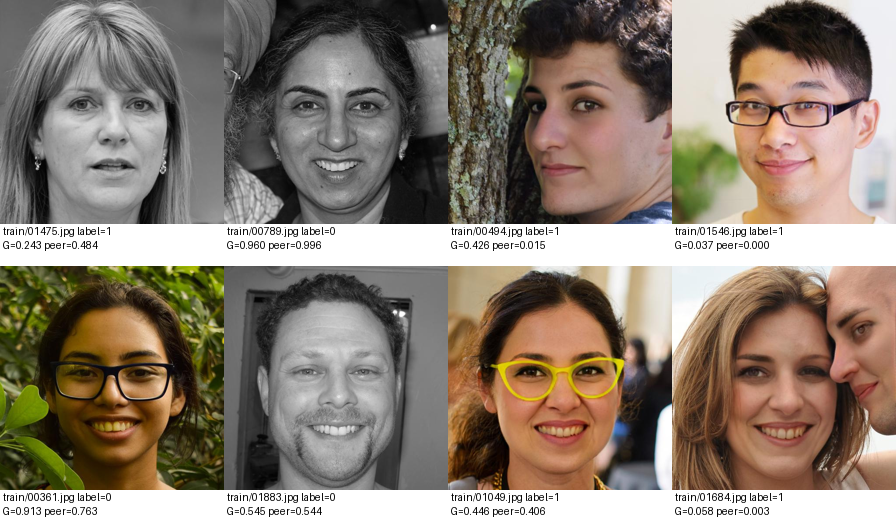

**global_only_vs_global_local__global_correct_peer_wrong**

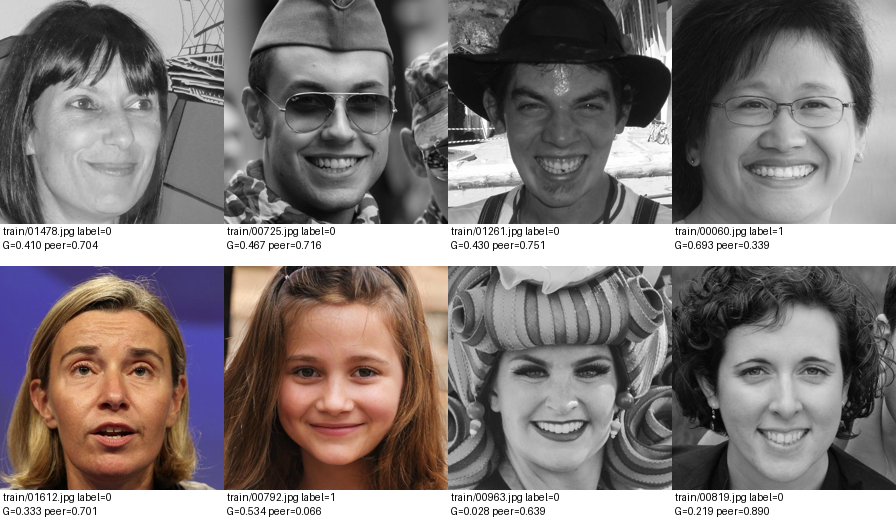

**global_only_vs_global_local__global_wrong_peer_correct**

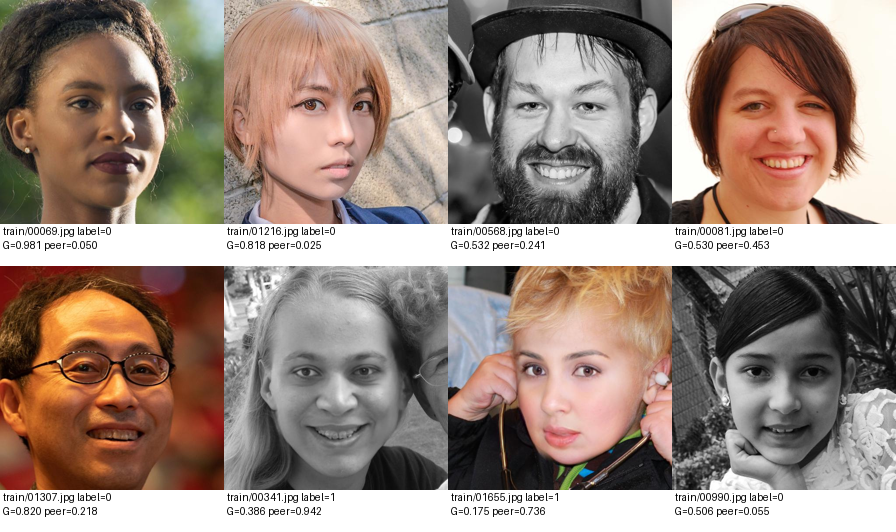

**global_only_vs_local_only__both_wrong**

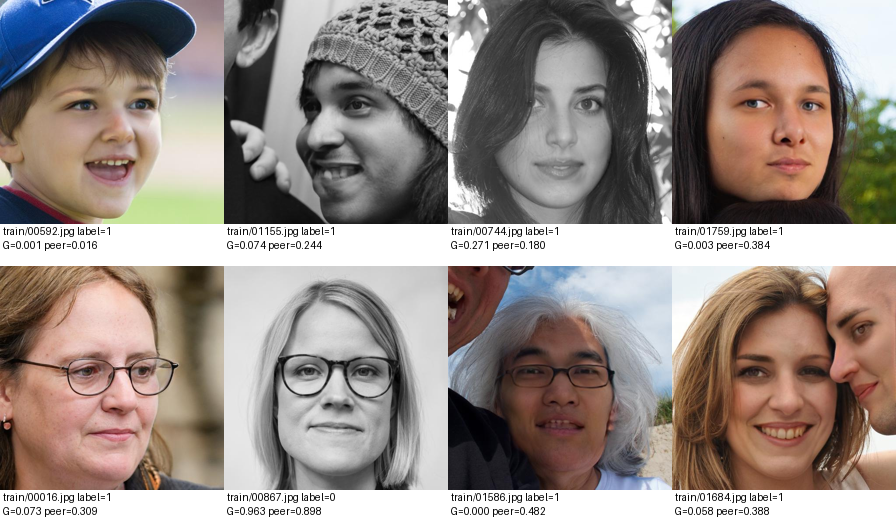

**global_only_vs_local_only__global_correct_peer_wrong**

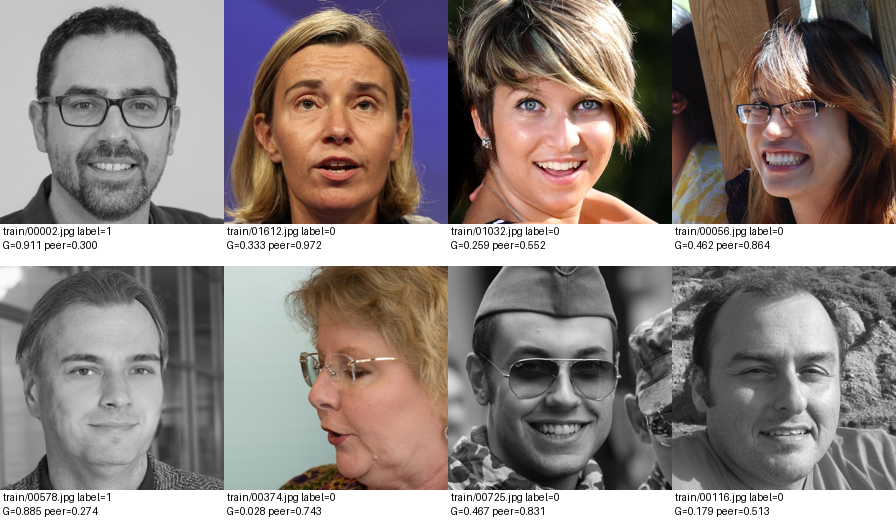

**global_only_vs_local_only__global_wrong_peer_correct**

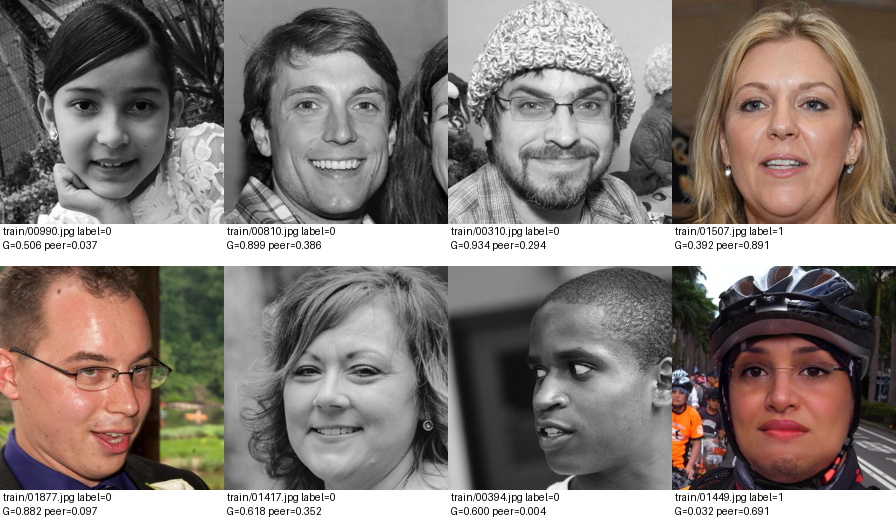

In [6]:
cases, case_counts = error_groups(cached_predictions)
cases.to_csv(OUTPUT_DIR / "error_cases.csv", index=False)
case_counts.to_csv(OUTPUT_DIR / "error_group_counts.csv", index=False)
display(case_counts)
montages = save_error_montages(cases, image_paths_by_id, OUTPUT_DIR / "error_montages", seed=SEED)
for path in montages:
    display(Markdown(f"**{path.stem}**"))
    display(DisplayImage(filename=str(path)))

# Montage là mẫu seed 42 để xem lỗi; không dùng hình này làm bằng chứng vùng model chú ý.


In [7]:
HF_TOKEN = os.environ.get("HF_TOKEN")
if not HF_TOKEN:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
if not HF_TOKEN:
    raise RuntimeError("Thiết lập Kaggle Secret HF_TOKEN đã có quyền model.")
from huggingface_hub import login
login(token=HF_TOKEN, add_to_git_credential=False)
del HF_TOKEN

from transformers import AutoImageProcessor
from src.models.dinov3 import DINOv3FeatureExtractor

MODEL_ID = cache["manifest"]["model_id"]
REVISION = cache["manifest"]["model_revision"]
PROCESSOR_DIR = Path("/kaggle/working/phase6_saved_processor")
PROCESSOR_DIR.mkdir(parents=True, exist_ok=True)
shutil.copy2(PHASE4_ROOT / "processor.json", PROCESSOR_DIR / "preprocessor_config.json")
saved_processor_type = cache["processor"]["image_processor_type"]
processor = AutoImageProcessor.from_pretrained(
    PROCESSOR_DIR, local_files_only=True, use_fast=saved_processor_type.endswith("Fast"),
)
PROCESSOR_KEYS = [
    "image_processor_type", "size", "resample", "do_resize", "do_center_crop", "crop_size",
    "do_convert_rgb", "do_rescale", "rescale_factor", "do_normalize", "image_mean", "image_std",
]
for key in PROCESSOR_KEYS:
    if processor.to_dict().get(key) != cache["processor"].get(key):
        raise ValueError(f"Processor không khớp cache: {key}")
extractor = DINOv3FeatureExtractor(MODEL_ID, freeze=True, revision=REVISION).to(DEVICE).eval()
if getattr(extractor.backbone.config, "_commit_hash", None) != REVISION:
    raise ValueError("Model revision không khớp cache.")
print("Loaded Frozen DINOv3:", MODEL_ID, REVISION)


config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loaded Frozen DINOv3: facebook/dinov3-vitb16-pretrain-lvd1689m 5931719e67bbdb9737e363e781fb0c67687896bc


In [8]:
# Hai pass clean giúp tách ảnh hưởng precision khỏi thay đổi classifier.
clean_amp = extract_validation(
    extractor, processor, validation_paths, metadata, DEVICE,
    condition="clean", precision="amp_float16", batch_size=BATCH_SIZE,
)
clean_fp32 = extract_validation(
    extractor, processor, validation_paths, metadata, DEVICE,
    condition="clean", precision="float32", batch_size=BATCH_SIZE,
)
feature_checks = pd.concat([
    compare_features(cache["features"], clean_amp, "cache_vs_clean_amp"),
    compare_features(clean_amp, clean_fp32, "clean_amp_vs_clean_float32"),
], ignore_index=True)
feature_checks.to_csv(OUTPUT_DIR / "feature_precision_checks.csv", index=False)
display(feature_checks)
if (feature_checks[feature_checks.comparison == "cache_vs_clean_amp"].min_cosine_similarity < 0.9999).any():
    raise ValueError("Clean extraction khác cache đáng kể; kiểm tra dataset/processor trước robustness.")

amp_predictions = predict_features(heads, clean_amp, metadata, DEVICE, "clean_amp", BATCH_SIZE)
fp32_predictions = predict_features(heads, clean_fp32, metadata, DEVICE, "clean_float32", BATCH_SIZE)
precision_predictions = pd.concat([cached_predictions, amp_predictions, fp32_predictions], ignore_index=True)
precision_metrics = score_predictions(precision_predictions)
precision_predictions.to_csv(OUTPUT_DIR / "precision_predictions.csv", index=False)
precision_metrics.to_csv(OUTPUT_DIR / "precision_metrics.csv", index=False)
display(precision_metrics)

phase3_diagnostic = {"artifact_attached": PHASE3_ROOT is not None}
if PHASE3_ROOT is not None:
    old_head, old_checkpoint = load_classifier(PHASE3_ROOT / "mlp/best_classifier.pt", 768, DEVICE)
    if (old_checkpoint["backbone"] != MODEL_ID or old_checkpoint["resolved_model_commit"] != REVISION
            or old_checkpoint["image_size"] != 224):
        raise ValueError("Phase 3 backbone/revision/image size không khớp.")
    for key in PROCESSOR_KEYS:
        if old_checkpoint["processor"].get(key) != cache["processor"].get(key):
            raise ValueError(f"Phase 3 preprocessing khác: {key}")
    old_predictions = pd.concat([
        predict_features({"global_only": old_head}, cache["features"], metadata, DEVICE, "phase3_head_on_cache", BATCH_SIZE),
        predict_features({"global_only": old_head}, clean_fp32, metadata, DEVICE, "phase3_head_on_float32", BATCH_SIZE),
    ], ignore_index=True)
    old_metrics = score_predictions(old_predictions)
    old_predictions.to_csv(OUTPUT_DIR / "phase3_checkpoint_predictions.csv", index=False)
    old_metrics.to_csv(OUTPUT_DIR / "phase3_checkpoint_metrics.csv", index=False)
    original_phase3 = json.loads((PHASE3_ROOT / "results.json").read_text())["mlp"]
    observed = old_metrics[old_metrics.condition == "phase3_head_on_float32"].iloc[0]
    phase3_diagnostic.update({
        "best_epoch": old_checkpoint["best_epoch"],
        "original_reported_metrics": original_phase3["metrics"],
        "float32_metric_deltas_vs_original": {
            name: float(observed[name] - original_phase3["metrics"][f"val_{name}"])
            for name in ["auroc", "balanced_accuracy", "accuracy", "f1"]
        },
        "checkpoint_sha256": file_hash(PHASE3_ROOT / "mlp/best_classifier.pt"),
    })
    display(old_metrics)
else:
    phase3_diagnostic["limitation"] = "Thiếu checkpoint Phase 3; chỉ đo precision với checkpoint Phase 5. Chưa xác định nguyên nhân toàn bộ chênh lệch giữa hai run."
save_json("phase3_diagnostic.json", phase3_diagnostic)


clean/amp_float16:   0%|          | 0/13 [00:00<?, ?it/s]

clean/float32:   0%|          | 0/13 [00:00<?, ?it/s]

,comparison,branch,mean_absolute_difference,max_absolute_difference,mean_cosine_similarity,min_cosine_similarity
0,cache_vs_clean_amp,global,0.000000,0.000000,1.000000,1.000000
1,cache_vs_clean_amp,local,0.000000,0.000000,1.000000,1.000000
2,clean_amp_vs_clean_float32,global,0.000794,0.012034,0.999998,0.999981
3,clean_amp_vs_clean_float32,local,0.000266,0.006062,0.999999,0.999993


,condition,representation,n_images,balanced_accuracy,accuracy,f1,auroc
0,clean_cached,global_only,400,0.8400,0.8400,0.842365,0.930025
1,clean_cached,local_only,400,0.8825,0.8825,0.885645,0.952550
2,clean_cached,global_local,400,0.8725,0.8725,0.873449,0.945550
3,clean_amp,global_only,400,0.8400,0.8400,0.842365,0.930025
4,clean_amp,local_only,400,0.8825,0.8825,0.885645,0.952550
5,clean_amp,global_local,400,0.8725,0.8725,0.873449,0.945550
6,clean_float32,global_only,400,0.8400,0.8400,0.842365,0.930075
7,clean_float32,local_only,400,0.8825,0.8825,0.885645,0.952575
8,clean_float32,global_local,400,0.8725,0.8725,0.873449,0.945575


,condition,representation,n_images,balanced_accuracy,accuracy,f1,auroc
0,phase3_head_on_cache,global_only,400,0.87,0.87,0.857143,0.932225
1,phase3_head_on_float32,global_only,400,0.87,0.87,0.857143,0.932275


jpeg_q70/amp_float16:   0%|          | 0/13 [00:00<?, ?it/s]

resize_112_224/amp_float16:   0%|          | 0/13 [00:00<?, ?it/s]

blur_r1/amp_float16:   0%|          | 0/13 [00:00<?, ?it/s]

,condition,representation,auroc,balanced_accuracy,f1,delta_auroc_vs_clean,delta_balanced_accuracy_vs_clean
0,clean,global_only,0.930025,0.8400,0.842365,0.000000,0.0000
1,clean,local_only,0.952550,0.8825,0.885645,0.000000,0.0000
2,clean,global_local,0.945550,0.8725,0.873449,0.000000,0.0000
3,jpeg_q70,global_only,0.928600,0.8300,0.832512,-0.001425,-0.0100
4,jpeg_q70,local_only,0.950525,0.8825,0.885086,-0.002025,0.0000
5,jpeg_q70,global_local,0.944700,0.8825,0.882206,-0.000850,0.0100
6,resize_112_224,global_only,0.903000,0.8100,0.810945,-0.027025,-0.0300
7,resize_112_224,local_only,0.925675,0.8300,0.844037,-0.026875,-0.0525
8,resize_112_224,global_local,0.918025,0.8400,0.841584,-0.027525,-0.0325
9,blur_r1,global_only,0.927700,0.8450,0.844221,-0.002325,0.0050


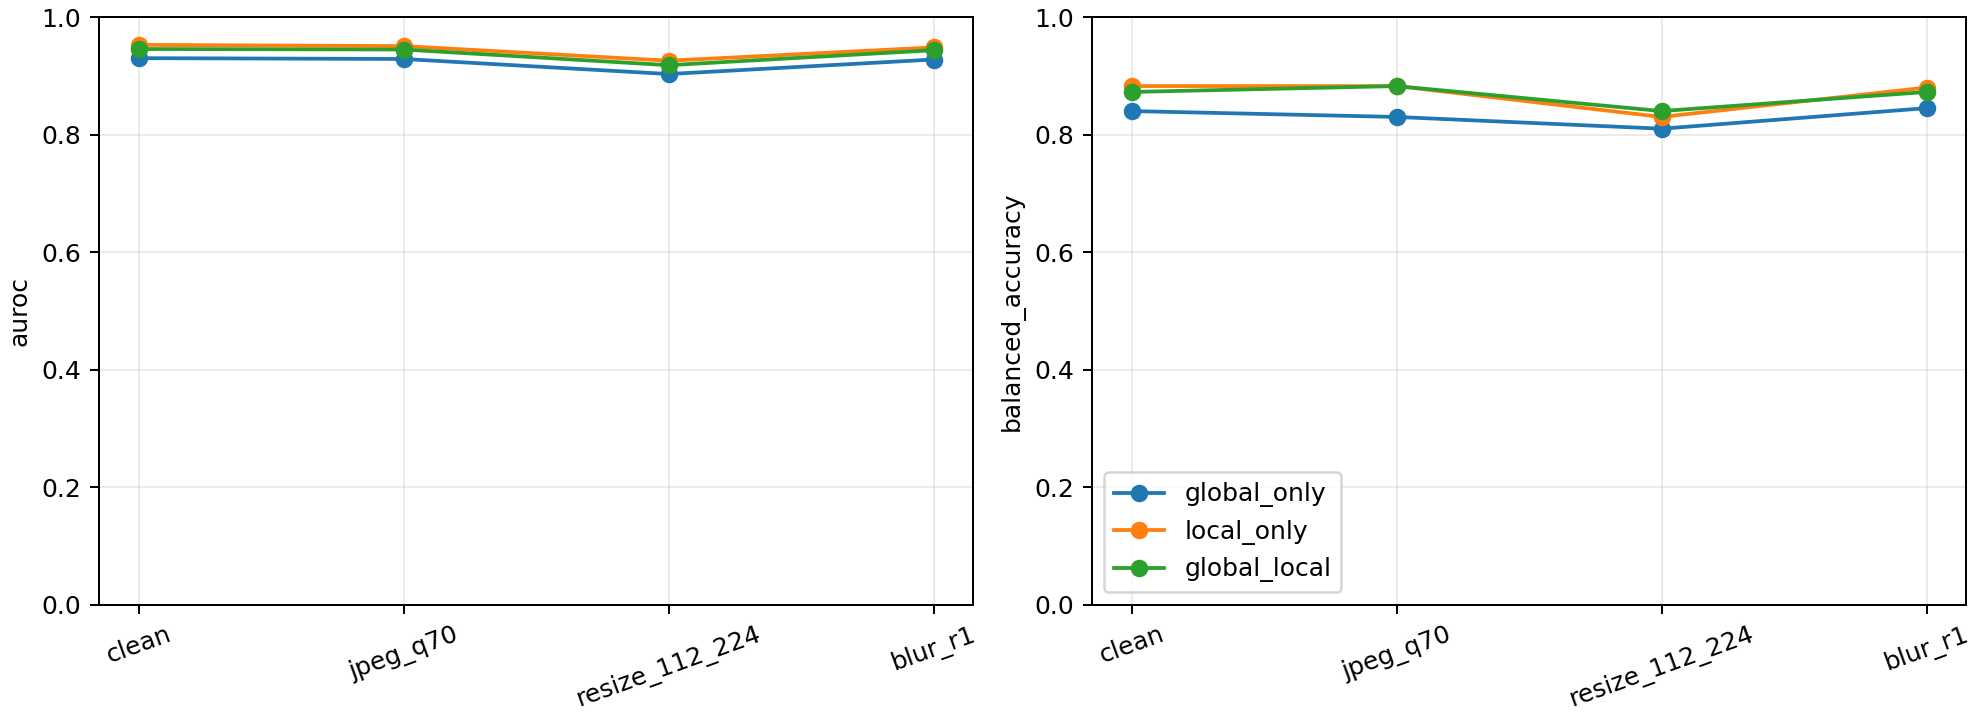

In [9]:
# Mỗi corruption bắt đầu từ RGB gốc; dùng đúng các head đã kiểm tra ở trên.
clean_predictions = amp_predictions.copy()
clean_predictions["condition"] = "clean"
robustness_frames = [clean_predictions]
for condition in CONDITIONS:
    if condition == "clean":
        continue
    values = extract_validation(
        extractor, processor, validation_paths, metadata, DEVICE,
        condition=condition, precision="amp_float16", batch_size=BATCH_SIZE,
    )
    robustness_frames.append(
        predict_features(heads, values, metadata, DEVICE, condition, BATCH_SIZE)
    )

robustness_predictions = pd.concat(robustness_frames, ignore_index=True)
if len(robustness_predictions) != 400 * 3 * len(CONDITIONS):
    raise ValueError("Thiếu ảnh hoặc nhánh trong robustness.")
if robustness_predictions.duplicated(["condition", "representation", "image_id"]).any():
    raise ValueError("Robustness có ID trùng trong một condition/representation.")
robustness_predictions.to_csv(OUTPUT_DIR / "robustness_predictions.csv", index=False)
robustness_metrics = robustness_deltas(score_predictions(robustness_predictions))
robustness_metrics.to_csv(OUTPUT_DIR / "robustness_metrics.csv", index=False)
display(robustness_metrics[[
    "condition", "representation", "auroc", "balanced_accuracy", "f1",
    "delta_auroc_vs_clean", "delta_balanced_accuracy_vs_clean",
]])
save_robustness_plot(robustness_metrics, OUTPUT_DIR / "robustness.png")
display(DisplayImage(filename=str(OUTPUT_DIR / "robustness.png")))


In [10]:
# Ghi nhận xét quan sát sau khi xem montage. Có thể cập nhật cell này và chạy lại hai cell cuối.
OBSERVATION_NOTES = ""
save_json("error_observations.json", {
    "notes": OBSERVATION_NOTES,
    "status": "recorded" if OBSERVATION_NOTES.strip() else "pending visual review",
    "scope": "mẫu validation seed 42; checkpoint cũng được chọn bằng validation",
})

phase5_table = pd.DataFrame([
    {"representation": name, "best_epoch": phase5_results[name]["best_epoch"],
     **phase5_results[name]["metrics"]} for name in REPRESENTATIONS
])
summary = {
    "model_id": MODEL_ID, "model_revision": REVISION, "seed": SEED,
    "dataset": "Who Is AI; 2000 labeled images; source/generator unavailable",
    "split_counts": cache["counts"], "threshold": 0.5,
    "protocol": "MLP hidden 256; mean patch pooling; concat; no branch normalization",
    "classifier_config": phase5_config["model"], "training_config": phase5_config["training"],
    "phase4_cache_reload": "verified",
    "phase5_checkpoint_replay": replay_status.to_dict(orient="records"),
    "phase5_metrics": phase5_table.to_dict(orient="records"),
    "error_groups": case_counts.to_dict(orient="records"),
    "robustness_metrics": robustness_metrics.to_dict(orient="records"),
    "precision_metrics": precision_metrics.to_dict(orient="records"),
    "feature_precision_checks": feature_checks.to_dict(orient="records"),
    "phase3_diagnostic": phase3_diagnostic,
    "visual_observations": OBSERVATION_NOTES,
    "H1": "chưa xác định được; không có unseen-source test",
    "limitations": [
        "Một split in-domain và một seed.",
        "Checkpoint được chọn và phân tích trên cùng validation.",
        "Concat tăng input dimension của MLP nên số tham số của nhánh fusion lớn hơn.",
        "Robustness chỉ gồm ba corruption cố định, chưa đại diện cho biến đổi tổng quát.",
    ],
    "week3_priority": "Bổ sung source/generator metadata hoặc dataset có nguồn xác định để đánh giá unseen-source; Local-only là ứng viên theo kết quả in-domain.",
    "status": "quantitative summary generated; review outputs and observations before final Week 2 report",
}
save_json("week02_summary.json", summary)

def markdown_table(frame, columns):
    subset = frame[columns]
    lines = ["| " + " | ".join(columns) + " |", "| " + " | ".join("---" for _ in columns) + " |"]
    for row in subset.itertuples(index=False, name=None):
        lines.append("| " + " | ".join(f"{value:.6f}" if isinstance(value, float) else str(value) for value in row) + " |")
    return "\n".join(lines)

report = "## Tổng hợp tuần 2\n\n" + markdown_table(
    phase5_table, ["representation", "best_epoch", "val_auroc", "val_balanced_accuracy", "val_f1"]
)
report += "\n\n### Robustness trên validation\n\n" + markdown_table(
    robustness_metrics, ["condition", "representation", "auroc", "balanced_accuracy", "delta_auroc_vs_clean", "delta_balanced_accuracy_vs_clean"]
)
report += "\n\nH1: **chưa xác định được** vì chưa có unseen-source test. Local-only là ứng viên dựa trên kết quả in-domain."
report += "\n\nNhận xét ảnh: " + (OBSERVATION_NOTES.strip() or "Chờ xem montage và ghi nhận xét.")
report += "\n\nChênh lệch Phase 3/5: xem precision_metrics.csv, feature_precision_checks.csv và phase3_diagnostic.json; không suy ra nguyên nhân chỉ từ bảng metrics hai run."
display(Markdown(report))


## Tổng hợp tuần 2

| representation | best_epoch | val_auroc | val_balanced_accuracy | val_f1 |
| --- | --- | --- | --- | --- |
| global_only | 7 | 0.930025 | 0.840000 | 0.842365 |
| local_only | 7 | 0.952550 | 0.882500 | 0.885645 |
| global_local | 14 | 0.945550 | 0.872500 | 0.873449 |

### Robustness trên validation

| condition | representation | auroc | balanced_accuracy | delta_auroc_vs_clean | delta_balanced_accuracy_vs_clean |
| --- | --- | --- | --- | --- | --- |
| clean | global_only | 0.930025 | 0.840000 | 0.000000 | 0.000000 |
| clean | local_only | 0.952550 | 0.882500 | 0.000000 | 0.000000 |
| clean | global_local | 0.945550 | 0.872500 | 0.000000 | 0.000000 |
| jpeg_q70 | global_only | 0.928600 | 0.830000 | -0.001425 | -0.010000 |
| jpeg_q70 | local_only | 0.950525 | 0.882500 | -0.002025 | 0.000000 |
| jpeg_q70 | global_local | 0.944700 | 0.882500 | -0.000850 | 0.010000 |
| resize_112_224 | global_only | 0.903000 | 0.810000 | -0.027025 | -0.030000 |
| resize_112_224 | local_only | 0.925675 | 0.830000 | -0.026875 | -0.052500 |
| resize_112_224 | global_local | 0.918025 | 0.840000 | -0.027525 | -0.032500 |
| blur_r1 | global_only | 0.927700 | 0.845000 | -0.002325 | 0.005000 |
| blur_r1 | local_only | 0.948275 | 0.880000 | -0.004275 | -0.002500 |
| blur_r1 | global_local | 0.943550 | 0.872500 | -0.002000 | 0.000000 |

H1: **chưa xác định được** vì chưa có unseen-source test. Local-only là ứng viên dựa trên kết quả in-domain.

Nhận xét ảnh: Chờ xem montage và ghi nhận xét.

Chênh lệch Phase 3/5: xem precision_metrics.csv, feature_precision_checks.csv và phase3_diagnostic.json; không suy ra nguyên nhân chỉ từ bảng metrics hai run.

In [11]:
required_outputs = [
    "protocol_environment.json", "checkpoint_replay.csv", "error_cases.csv", "error_group_counts.csv",
    "precision_metrics.csv", "feature_precision_checks.csv", "phase3_diagnostic.json",
    "robustness_metrics.csv", "robustness_predictions.csv", "week02_summary.json",
    "cached_validation_predictions.csv", "precision_predictions.csv", "error_observations.json",
    "validation_metadata.csv", "val.csv", "cache_manifest.json", "processor.json", "phase5_config.yaml",
]
missing_outputs = [name for name in required_outputs if not (OUTPUT_DIR / name).is_file()]
if missing_outputs:
    raise FileNotFoundError(missing_outputs)
# Kiểm tra reload bảng predictions đã lưu, trước khi đóng gói.
saved_predictions = pd.read_csv(OUTPUT_DIR / "robustness_predictions.csv", keep_default_na=False)
if len(saved_predictions) != 4800:
    raise ValueError("Prediction output reload không đủ 4800 hàng.")
for (_, _), group in saved_predictions.groupby(["condition", "representation"]):
    if group.image_id.tolist() != metadata.image_id.tolist() or group.label.tolist() != metadata.label.tolist():
        raise ValueError("Thứ tự ID/label output đã lưu không khớp validation.")
archive = shutil.make_archive("/kaggle/working/phase6_analysis_artifacts", "zip", root_dir=OUTPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Artifact ZIP:", archive)
print("Save Version để giữ output. Gửi notebook output này để cập nhật tổng hợp cuối trong week02.md.")


Output directory: /kaggle/working/phase6_outputs/dinov3_seed42
Artifact ZIP: /kaggle/working/phase6_analysis_artifacts.zip
Save Version để giữ output. Gửi notebook output này để cập nhật tổng hợp cuối trong week02.md.
